In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/train.csv', sep=',')

In [4]:
with open('../data/data_description.txt', 'r') as f:
  description = f.read()

print(description)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

Для начала избавимся от признаков, заполненных менее чем на половину. В таком случае будет оправдано удалить колонки

In [5]:
print(f'Пропусков до - {df.isnull().sum().sum()}')
print(df.isnull().sum().sort_values(ascending=False))

Пропусков до - 7829
PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64


In [6]:
df = df.dropna(axis=1, thresh=len(df) / 2)
df.isnull().sum().sort_values(ascending=False)

FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageQual        81
GarageFinish      81
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 76, dtype: int64

FireplaceQu: Fireplace quality

       Ex	Excellent - Exceptional Masonry Fireplace
       Gd	Good - Masonry Fireplace in main level
       TA	Average - Prefabricated Fireplace in main living area or Masonry Fireplace in basement
       Fa	Fair - Prefabricated Fireplace in basement
       Po	Poor - Ben Franklin Stove
       NA	No Fireplace

Согласно документации - NA не потерянная информация, это признак отстутствия

In [7]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')
df['FireplaceQu'].isnull().sum()

np.int64(0)

LotFrontage: Linear feet of street connected to property

Отсутствие признака можно заполнить средним LotFrontage для определенного Neighborhood. 

In [8]:
df['LotFrontage'] = df.groupby(['Neighborhood'])['LotFrontage'].transform(lambda x: x.fillna(x.mean()))

GarageYrBlt: Year garage was built
		
GarageFinish: Interior finish of the garage

       Fin	Finished
       RFn	Rough Finished	
       Unf	Unfinished
       NA	No Garage
		
GarageCars: Size of garage in car capacity

GarageArea: Size of garage in square feet

GarageQual: Garage quality

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage
		
GarageCond: Garage condition

       Ex	Excellent
       Gd	Good
       TA	Typical/Average
       Fa	Fair
       Po	Poor
       NA	No Garage

Для гаражей - 81 пропуск. Имеет смысл утверждение, что для 81 дома гаражей просто нет

In [9]:
garage_cols = [g for g in df.columns if g.startswith('Garage')]
df[garage_cols].isnull().sum()

GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageCars       0
GarageArea       0
GarageQual      81
GarageCond      81
dtype: int64

In [10]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

category_garage_cols = df[garage_cols].select_dtypes(include=['object', 'string']).columns

df[category_garage_cols] = df[category_garage_cols].fillna('None')

df[garage_cols].isnull().sum().sum()

np.int64(0)

In [11]:
df.isnull().sum().sort_values(ascending=False)

BsmtExposure     38
BsmtFinType2     38
BsmtCond         37
BsmtQual         37
BsmtFinType1     37
                 ..
MoSold            0
YrSold            0
SaleType          0
SaleCondition     0
SalePrice         0
Length: 76, dtype: int64

BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement

BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement

BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

Из документации можно заметить, что NA означает не потерянные данные, а отстутствие подвала

In [12]:
bsmt_cols = [b for b in df.columns if b.startswith('Bsmt')]
df[bsmt_cols].isnull().sum()

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinSF1       0
BsmtFinType2    38
BsmtFinSF2       0
BsmtUnfSF        0
BsmtFullBath     0
BsmtHalfBath     0
dtype: int64

Тут заметно несоответствие. Где-то 37 пропусков, а где-то 38. Это означает, что есть пропущенная информация в 1 строке.

In [13]:
row1 = df[(df['BsmtQual'].notnull()) & (df['BsmtExposure'].isnull())]
row2 = df[(df['BsmtQual'].notnull()) & (df['BsmtFinType2'].isnull())]

print(row1.shape[0])
print(row2.shape[0])

1
1


In [14]:
df[['BsmtQual', 'BsmtCond', 'BsmtFinType1']] = df[['BsmtQual', 'BsmtCond', 'BsmtFinType1']].fillna('None')

In [15]:
df['BsmtExposure'] = df['BsmtExposure'].fillna('No')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('Unf')

In [16]:
df.isnull().sum().sort_values(ascending=False)

MasVnrArea       8
Electrical       1
Id               0
MSSubClass       0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64

MasVnrType: Masonry veneer type

       BrkCmn	Brick Common
       BrkFace	Brick Face
       CBlock	Cinder Block
       None	        None
       Stone	Stone

In [17]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

elec_mode = df['Electrical'].mode()[0]
df['Electrical'] = df['Electrical'].fillna(elec_mode)

print(elec_mode)

SBrkr


Рассмотрим топ 5 числовых признаков, влияющих сильнее всего на целевую переменную. Возьмем каждый из них и проверим на выбросы. Мы делаем это для лучшей работы нашей модели.

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns

top_features = df[num_cols].corr()['SalePrice'].abs().sort_values(ascending=False)[1:6]
top_features
 

OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64

<Axes: xlabel='OverallQual', ylabel='SalePrice'>

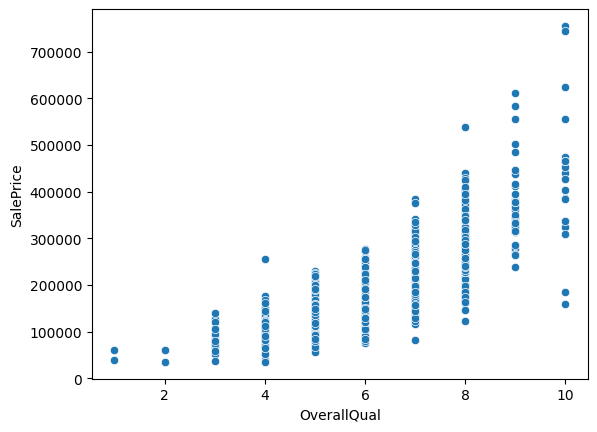

In [ ]:
sns.scatterplot(x='OverallQual', y='SalePrice', data=df);

In [20]:
df[(df['OverallQual'] == 10) & (df['SalePrice'] < 200000)][['OverallQual', 'GrLivArea', 'Neighborhood', 'SaleCondition', 'SalePrice']]

,OverallQual,GrLivArea,Neighborhood,SaleCondition,SalePrice
523,10,4676,Edwards,Partial,184750
1298,10,5642,Edwards,Partial,160000


Дома с OverallQual=10 и низкой ценой имеют SaleCondition=Partial (продажа недостроенного жилья) - это обоснованная низкая цена, не аномалия. Удалению не подлежат, модель будет это учить.

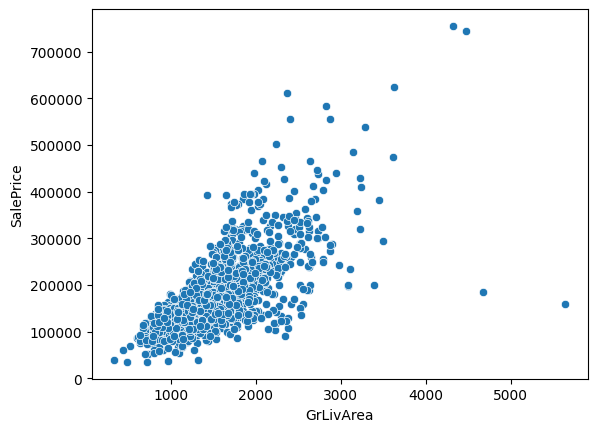

In [21]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df);

In [22]:
df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)][['OverallQual', 'GrLivArea', 'Neighborhood', 'SaleCondition', 'SalePrice']]

,OverallQual,GrLivArea,Neighborhood,SaleCondition,SalePrice
523,10,4676,Edwards,Partial,184750
1298,10,5642,Edwards,Partial,160000


На графике для SalePrice от GrLivArea заметны 2 явных выброса с большой площадью, но низкой ценой. Оказалось это те же 2 недостроенных дома, удалять не будем.

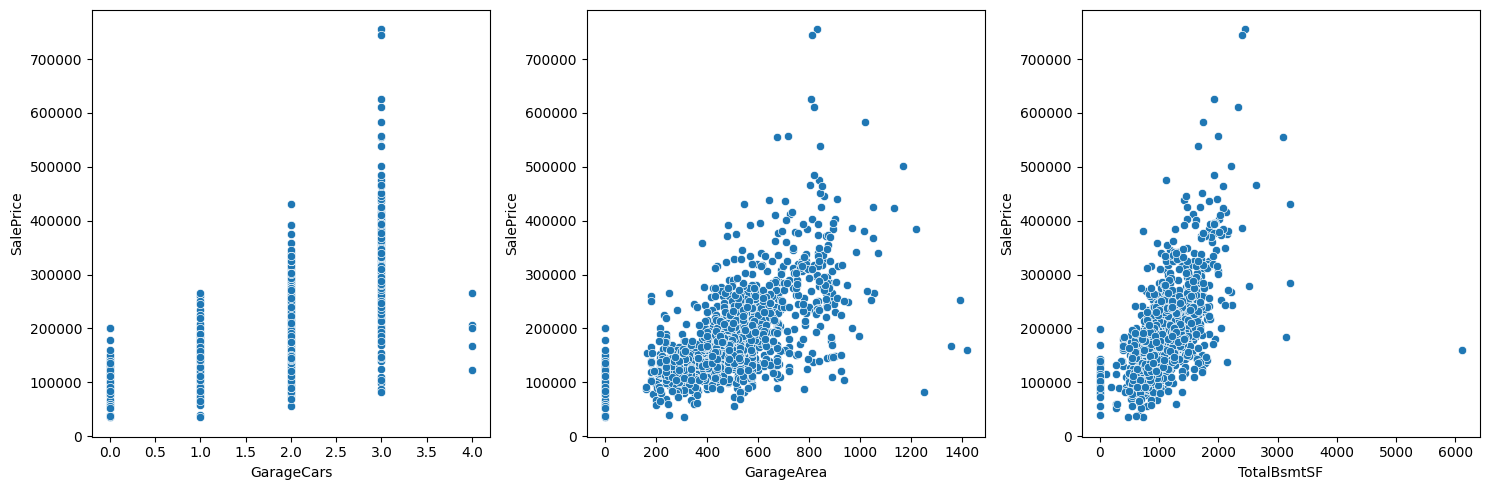

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(x='GarageCars', y='SalePrice', data=df, ax=axes[0])
sns.scatterplot(x='GarageArea', y='SalePrice', data=df, ax=axes[1])
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df, ax=axes[2])

plt.tight_layout()
plt.show()

In [24]:
df[(df['TotalBsmtSF'] > 6000) & (df['SalePrice'] < 200000)][['OverallQual', 'GrLivArea', 'Neighborhood', 'SaleCondition', 'SalePrice']]

,OverallQual,GrLivArea,Neighborhood,SaleCondition,SalePrice
1298,10,5642,Edwards,Partial,160000


Проверены топ 5 признаков, аномалии по признаку связаны с SaleCondition = Partial (продажей недостроенного дома). Для каждого проверенного признака - это одни и те же дома.

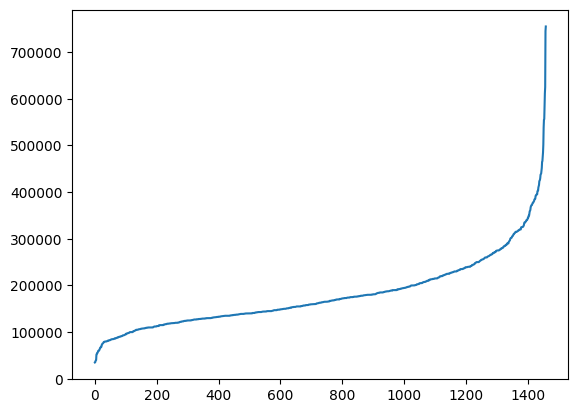

In [25]:
sale_price = df['SalePrice'].sort_values(ascending=True).reset_index(drop=True)

plt.plot(sale_price.index, sale_price.values)

0       10.460271
1       10.471978
2       10.542733
3       10.579005
4       10.596660
          ...    
1455    13.275829
1456    13.323929
1457    13.345509
1458    13.521141
1459    13.534474
Name: SalePrice, Length: 1460, dtype: float64


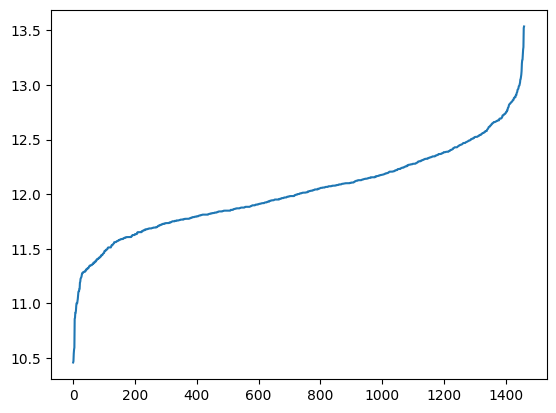

In [26]:
df['SalePrice'] = np.log1p(df['SalePrice'])

sale_price = df['SalePrice'].sort_values(ascending=True).reset_index(drop=True)
print(sale_price)

plt.plot(sale_price.values)

In [27]:
df[['OverallQual', 'OverallCond']].dtypes

OverallQual    int64
OverallCond    int64
dtype: object

In [28]:
df.to_csv('../data/df-no-passes.csv')

### train test split

In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

Id - порядковый номер строки, не несет информации для модели.

### feature engeneering

In [30]:
X_train['TotalSF'] = X_train['TotalBsmtSF'] + X_train['1stFlrSF'] + X_train['2ndFlrSF']
X_train['HouseAge'] = X_train['YrSold'] - X_train['YearBuilt']

X_test['TotalSF'] = X_test['TotalBsmtSF'] + X_test['1stFlrSF'] + X_test['2ndFlrSF']
X_test['HouseAge'] = X_test['YrSold'] - X_test['YearBuilt']

### one hot encoding

In [31]:
category_cols = X_train.select_dtypes(include=['string', 'category']).columns

In [32]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoder.fit(X_train[category_cols])

encoded_train = encoder.transform(X_train[category_cols])
encoded_test = encoder.transform(X_test[category_cols])

column_name = encoder.get_feature_names_out(category_cols)

encoded_df_train = pd.DataFrame(data=encoded_train, columns=column_name, index=X_train.index)
encoded_df_test = pd.DataFrame(data=encoded_test, columns=column_name, index=X_test.index)

X_train = pd.concat([X_train.drop(columns=category_cols), encoded_df_train], axis=1)
X_test = pd.concat([X_test.drop(columns=category_cols), encoded_df_test], axis=1)

c:\Users\Татустик\Desktop\my git\kaggle-house-prices\lomavisc\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [13, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Scaling

In [33]:
num_cols = X_train.select_dtypes(include=[np.number]).columns
num_cols

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='str', length=241)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [35]:
import os

os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=True)
X_test.to_csv('../data/processed/X_test.csv', index=True)
y_train.to_csv('../data/processed/y_train.csv', index=True)
y_test.to_csv('../data/processed/y_test.csv', index=True)

In [36]:
cols_to_drop = ['GarageArea', '1stFlrSF', 'TotRmsAbvGrd']

X_train.drop(columns=cols_to_drop).to_csv('../data/processed/X_train_lr.csv', index=True)
X_test.drop(columns=cols_to_drop).to_csv('../data/processed/X_test_lr.csv', index=True)